In [23]:
from pctk import multicellds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, FormatStrFormatter
import os
import numpy as np
from itertools import product

# Study of the convergence in 3D  with an homogeneous initial condition of 10 for the 10 size voxel.

In [24]:
output_path = "../../../size_10"

In [25]:
reader = multicellds.MultiCellDS(output_folder=output_path)

In [26]:
# --- data collection ---
center_indices = None
center_count   = None
center_vals    = []
times          = []

for t, a in reader.microenvironment_as_matrix_iterator():
    arr_flat = a[4]             # flattened concentration array

    if center_indices is None:
        # infer grid size n³ from total voxels
        n_vox = arr_flat.size
        n     = int(round(n_vox ** (1/3)))
        dims  = (n, n, n)

        # for each axis, pick either the single middle (if odd)
        # or the two middle coordinates (if even):
        mids = []
        for d in dims:
            if d % 2 == 1:
                # odd → exact center
                mid = d // 2
                mids.append([mid])
            else:
                # even → two central positions
                mids.append([d//2 - 1, d//2])

        # build all combinations of central voxels
        center_coords = list(product(*mids))  # length=1 or 8
        center_indices = np.ravel_multi_index(
            tuple(zip(*center_coords)), dims
        )
        center_count = len(center_indices)

        print(f"Inferred grid: {dims}")
        print(f"Central coords: {center_coords}")
        print(f"Flattened central indices: {center_indices}")

    # grab the central voxel values and average them
    vals = arr_flat[center_indices]
    avg  = vals.mean()

    center_vals.append(avg)

dt    = 0.1
N     = len(center_vals)
times = np.arange(N) * dt    

Inferred grid: (24, 24, 24)
Central coords: [(11, 11, 11), (11, 11, 12), (11, 12, 11), (11, 12, 12), (12, 11, 11), (12, 11, 12), (12, 12, 11), (12, 12, 12)]
Flattened central indices: [6611 6612 6635 6636 7187 7188 7211 7212]


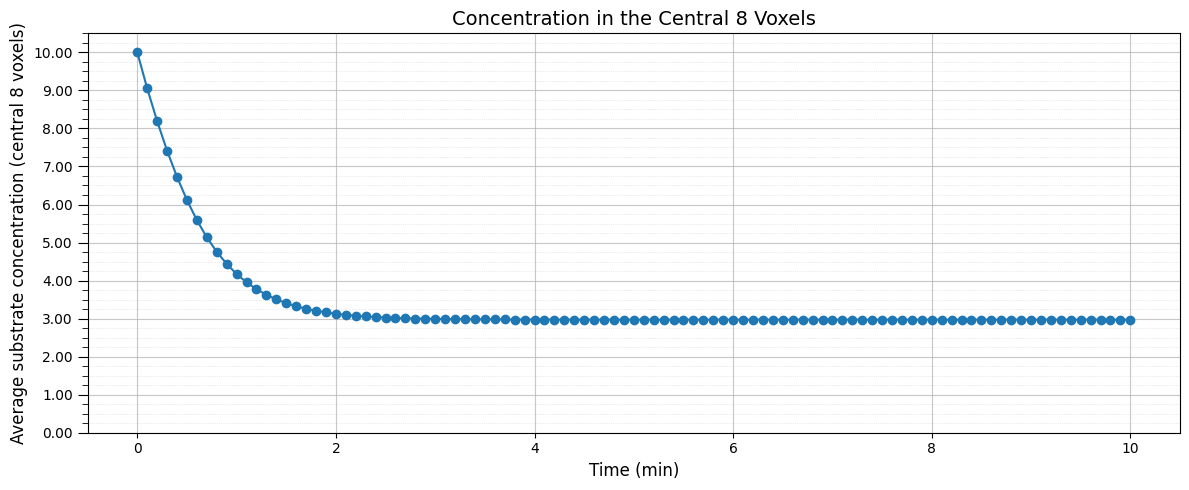

In [27]:
# --- build series & plot ---
series = pd.Series(center_vals,
                   index=pd.Index(times, name="time (min)"),
                   name=f"avg_{center_count}_central_voxels")

fig, ax = plt.subplots(figsize=(12, 5))
series.plot(ax=ax, marker='o', linestyle='-')

ymax = series.max()
ax.set_ylim(0, ymax * 1.05)
ax.yaxis.set_major_locator(MultipleLocator(ymax / 10))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel(f"Average substrate concentration (central {center_count} voxels)", fontsize=12)
ax.set_title(f"Concentration in the Central {center_count} Voxels", fontsize=14)

plt.tight_layout()
plt.show()

# Study of the convergence in 3D  with an homogeneous initial condition of 10 for the 20 size voxel.  The values are the sum of the 8 voxel in the center

In [28]:
output_path = "../../../size_20"

In [29]:
reader = multicellds.MultiCellDS(output_folder=output_path)

In [30]:
# --- data collection ---
center_indices = None
center_count   = None
center_vals    = []
times          = []

for t, a in reader.microenvironment_as_matrix_iterator():
    arr_flat = a[4]             # flattened concentration array

    if center_indices is None:
        # infer grid size n³ from total voxels
        n_vox = arr_flat.size
        n     = int(round(n_vox ** (1/3)))
        dims  = (n, n, n)

        # for each axis, pick either the single middle (if odd)
        # or the two middle coordinates (if even):
        mids = []
        for d in dims:
            if d % 2 == 1:
                # odd → exact center
                mid = d // 2
                mids.append([mid])
            else:
                # even → two central positions
                mids.append([d//2 - 1, d//2])

        # build all combinations of central voxels
        center_coords = list(product(*mids))  # length=1 or 8
        center_indices = np.ravel_multi_index(
            tuple(zip(*center_coords)), dims
        )
        center_count = len(center_indices)

        print(f"Inferred grid: {dims}")
        print(f"Central coords: {center_coords}")
        print(f"Flattened central indices: {center_indices}")

    # grab the central voxel values and average them
    vals = arr_flat[center_indices]
    avg  = vals.mean()

    center_vals.append(avg)

dt    = 0.1
N     = len(center_vals)
times = np.arange(N) * dt    

Inferred grid: (12, 12, 12)
Central coords: [(5, 5, 5), (5, 5, 6), (5, 6, 5), (5, 6, 6), (6, 5, 5), (6, 5, 6), (6, 6, 5), (6, 6, 6)]
Flattened central indices: [785 786 797 798 929 930 941 942]


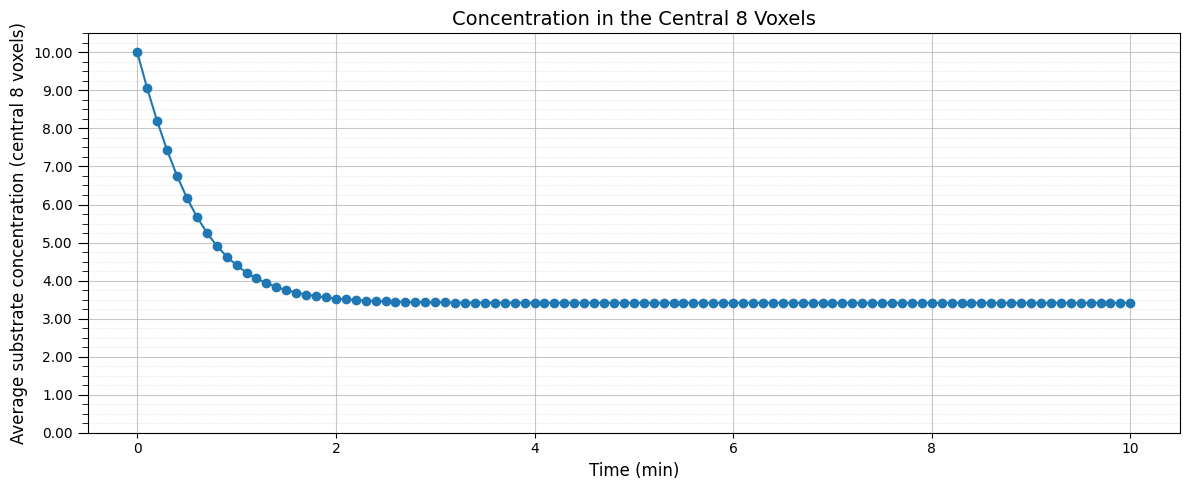

In [31]:
# --- build series & plot ---
series = pd.Series(center_vals,
                   index=pd.Index(times, name="time (min)"),
                   name=f"avg_{center_count}_central_voxels")

fig, ax = plt.subplots(figsize=(12, 5))
series.plot(ax=ax, marker='o', linestyle='-')

ymax = series.max()
ax.set_ylim(0, ymax * 1.05)
ax.yaxis.set_major_locator(MultipleLocator(ymax / 10))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel(f"Average substrate concentration (central {center_count} voxels)", fontsize=12)
ax.set_title(f"Concentration in the Central {center_count} Voxels", fontsize=14)

plt.tight_layout()
plt.show()

# Study of the convergence in 3D  with an homogeneous initial condition of 10 for the 40 size voxel. 

In [32]:
output_path = "./size_40/"

In [33]:
reader = multicellds.MultiCellDS(output_folder=output_path)

FileNotFoundError: [Errno 2] No such file or directory: './size_40/initial.xml'

In [ ]:
# --- data collection ---
center_indices = None
center_count   = None
center_vals    = []
times          = []

for t, a in reader.microenvironment_as_matrix_iterator():
    arr_flat = a[4]             # flattened concentration array

    if center_indices is None:
        # infer grid size n³ from total voxels
        n_vox = arr_flat.size
        n     = int(round(n_vox ** (1/3)))
        dims  = (n, n, n)

        # for each axis, pick either the single middle (if odd)
        # or the two middle coordinates (if even):
        mids = []
        for d in dims:
            if d % 2 == 1:
                # odd → exact center
                mid = d // 2
                mids.append([mid])
            else:
                # even → two central positions
                mids.append([d//2 - 1, d//2])

        # build all combinations of central voxels
        center_coords = list(product(*mids))  # length=1 or 8
        center_indices = np.ravel_multi_index(
            tuple(zip(*center_coords)), dims
        )
        center_count = len(center_indices)

        print(f"Inferred grid: {dims}")
        print(f"Central coords: {center_coords}")
        print(f"Flattened central indices: {center_indices}")

    # grab the central voxel values and average them
    vals = arr_flat[center_indices]
    avg  = vals.mean()

    center_vals.append(avg)

dt    = 0.1
N     = len(center_vals)
times = np.arange(N) * dt    

In [ ]:
# --- build series & plot ---
series = pd.Series(center_vals,
                   index=pd.Index(times, name="time (min)"),
                   name=f"avg_{center_count}_central_voxels")

fig, ax = plt.subplots(figsize=(12, 5))
series.plot(ax=ax, marker='o', linestyle='-')

ymax = series.max()
ax.set_ylim(0, ymax * 1.05)
ax.yaxis.set_major_locator(MultipleLocator(ymax / 10))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel(f"Average substrate concentration (central {center_count} voxels)", fontsize=12)
ax.set_title(f"Concentration in the Central {center_count} Voxels", fontsize=14)

plt.tight_layout()
plt.show()

# Convergence study

In [ ]:
# --- settings ---
base_path = "../../../"
folders   = ["size_10", "size_20", "size_40"]
dt        = 0.1   # minutes per time step

# prepare figure
fig, ax = plt.subplots(figsize=(12, 6))
global_max = 0.0

for folder in folders:
    # parse voxel size dh
    dh = float(folder.split("_")[1])

    # open that simulation
    sim_path = os.path.join(base_path, folder)
    reader   = multicellds.MultiCellDS(output_folder=sim_path)

    # collect central‐voxel averages
    center_indices = None
    center_vals    = []

    for t, a in reader.microenvironment_as_matrix_iterator():
        arr_flat = a[4]  # flattened concentration

        if center_indices is None:
            # infer n and dims
            n_vox = arr_flat.size
            n     = int(round(n_vox**(1/3)))
            dims  = (n, n, n)

            # pick 1 or 2 mids per axis
            mids = []
            for d in dims:
                if d % 2 == 1:
                    mids.append([d//2])
                else:
                    mids.append([d//2 - 1, d//2])

            # build all center coords and flatten
            center_coords  = list(product(*mids))
            coords_arr     = np.array(center_coords).T
            center_indices = np.ravel_multi_index(coords_arr, dims)
            center_count   = len(center_indices)

        # average those central voxels
        vals = arr_flat[center_indices]
        center_vals.append(vals.mean())

    # build a matching time vector
    N     = len(center_vals)
    times = np.arange(N) * dt

    # wrap in a Series and plot
    label = f"{int(dh)} μm voxels"
    series = pd.Series(center_vals,
                       index=pd.Index(times, name="Time (min)"),
                       name=label)
    series.plot(ax=ax, marker='o', linestyle='-')

    # track global max for y-limit
    global_max = max(global_max, series.max())

# finalize plot
ax.set_ylim(0, global_max * 1.05)
ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel("Central-voxel concentration", fontsize=12)
ax.set_title("Convergence study: central concentration vs. voxel size", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(title="Voxel size", loc="upper right")

plt.tight_layout()
plt.show()

# Study of the decay curve

In [ ]:
output_path = "./size_20"

In [ ]:
reader = multicellds.MultiCellDS(output_folder=output_path)

In [ ]:
# 1) Parameters you can tweak:
dt = 0.01        # minutes between outputs
# total_time can be changed to 1.0, 2.0, whatever
total_time = 5.0 

# --- extract central‐voxel concentration at each time ---
center_vals = []
flat_center = None

for _, a in reader.microenvironment_as_matrix_iterator():
    arr_flat = a[4]

    if flat_center is None:
        # infer grid dims
        n = int(round(arr_flat.size ** (1/3)))
        dims = (n, n, n)
        # exact center index
        mid = tuple(d // 2 for d in dims)
        flat_center = np.ravel_multi_index(mid, dims)

    center_vals.append(arr_flat[flat_center])

# 2) build a time‐axis that matches your outputs automatically
n_pts = len(center_vals)
times = np.arange(n_pts) * dt
# if you really want it to end exactly at total_time, you could do
# times = np.linspace(0, total_time, n_pts)

# 3) wrap in a Series (optional)
series = pd.Series(
    center_vals,
    index=pd.Index(times, name="time (min)"),
    name="central_voxel"
)

# --- plotting ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(series.index, series.values, marker='o', linestyle='-', linewidth=0.1, markersize=1)

# Y‐axis: start at 0 → 5% above max
ymax = series.max()
ax.set_ylim(0, ymax * 1.05)
ax.yaxis.set_major_locator(MultipleLocator(ymax / 10))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# X‐axis: 0 → final time, with major every total_time/10, minor every dt
final_t = series.index[-1]
ax.set_xlim(0, final_t)
ax.xaxis.set_major_locator(MultipleLocator(final_t / 10))
ax.xaxis.set_minor_locator(MultipleLocator(dt))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='x', which='major', length=7, labelsize=10, rotation=45)
ax.tick_params(axis='x', which='minor', length=4)

# grid, labels, title
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel("Central‐voxel concentration", fontsize=12)
ax.set_title(f"Central Voxel Decay (0 → {final_t:.2f} min)", fontsize=14)

plt.tight_layout()
plt.show()
